# Feature Engineering Pipeline

Build features for three ML models:
- **Model A**: Lap-level with tyre data (2019-2024, ~16 features)
- **Model B**: Lap-level without tyre data (2018-2025, ~11 features)
- **Model C**: Pre-race features (2018-2025, ~24 features)

All temporal features use shift(1) to prevent data leakage.

## 0. Setup & Data Loading

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from f1_predictor.features import (
    ExpandingWindowSplit,
    LeaveOneSeasonOut,
    build_lap_notyre_features,
    build_lap_tyre_features,
    build_race_features,
)

sns.set_theme(style="whitegrid")
DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

In [2]:
laps = pd.read_parquet(DATA_RAW / "laps" / "all_laps.parquet")
races = pd.read_parquet(DATA_RAW / "race" / "all_races.parquet")
print(f"Laps: {laps.shape[0]:,} rows, {laps.shape[1]} columns")
print(f"Races: {races.shape[0]:,} rows, {races.shape[1]} columns")

Laps: 165,128 rows, 19 columns
Races: 3,458 rows, 36 columns


## 1. Model A — Lap Features WITH Tyre (2019-2024)

In [3]:
tyre_laps = laps[laps["season"].between(2019, 2024)]
tyre_complete = tyre_laps["tire_compound"].notna().mean()
print(f"Tyre data completeness (2019-2024): {tyre_complete:.1%}")
print(f"Rows with tyre data: {tyre_laps['tire_compound'].notna().sum():,}")

Tyre data completeness (2019-2024): 99.7%
Rows with tyre data: 139,962


In [4]:
features_a = build_lap_tyre_features(laps)
print(f"Model A features: {features_a.shape}")
print(f"Columns: {list(features_a.columns)}")
features_a.head()

Model A features: (139962, 27)
Columns: ['season', 'round', 'event_name', 'driver_abbrev', 'team', 'lap_number', 'lap_time_delta_race_median', 'lap_time_rolling_3', 'lap_time_rolling_5', 'position_change_from_lap1', 'gap_to_leader', 'gap_to_ahead', 'laps_since_last_pit', 'pit_stop_count', 'race_progress_pct', 'is_pit_in_lap', 'is_pit_out_lap', 'compound_HARD', 'compound_INTERMEDIATE', 'compound_MEDIUM', 'compound_SOFT', 'compound_WET', 'tire_life', 'stint', 'degradation_rate', 'compound_pace_delta', 'position']


,season,round,event_name,driver_abbrev,team,lap_number,lap_time_delta_race_median,lap_time_rolling_3,lap_time_rolling_5,position_change_from_lap1,...,compound_HARD,compound_INTERMEDIATE,compound_MEDIUM,compound_SOFT,compound_WET,tire_life,stint,degradation_rate,compound_pace_delta,position
0,2019,1,Australian Grand Prix,ALB,Toro Rosso,1,12.391,NaN,NaN,0.0,...,0,0,0,1,0,1.0,1.0,0.0000,NaN,11.0
1,2019,1,Australian Grand Prix,ALB,Toro Rosso,2,2.348,101.7590,101.75900,0.0,...,0,0,0,1,0,2.0,1.0,0.0000,12.3910,11.0
2,2019,1,Australian Grand Prix,ALB,Toro Rosso,3,1.989,96.7375,96.73750,0.0,...,0,0,0,1,0,3.0,1.0,0.0000,7.3695,11.0
3,2019,1,Australian Grand Prix,ALB,Toro Rosso,4,2.053,94.9440,94.94400,0.0,...,0,0,0,1,0,4.0,1.0,-5.2010,2.3480,11.0
4,2019,1,Australian Grand Prix,ALB,Toro Rosso,5,1.516,91.4980,94.06325,0.0,...,0,0,0,1,0,5.0,1.0,-3.1373,2.2005,11.0


In [5]:
print("Missing values per column:")
missing = features_a.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal complete rows: {features_a.dropna().shape[0]:,} / {features_a.shape[0]:,}")

Missing values per column:
lap_time_delta_race_median    2332
lap_time_rolling_3            2925
lap_time_rolling_5            2570
position_change_from_lap1      207
gap_to_leader                 2332
gap_to_ahead                  2376
tire_life                      321
compound_pace_delta            427
position                       207
dtype: int64

Total complete rows: 134,183 / 139,962


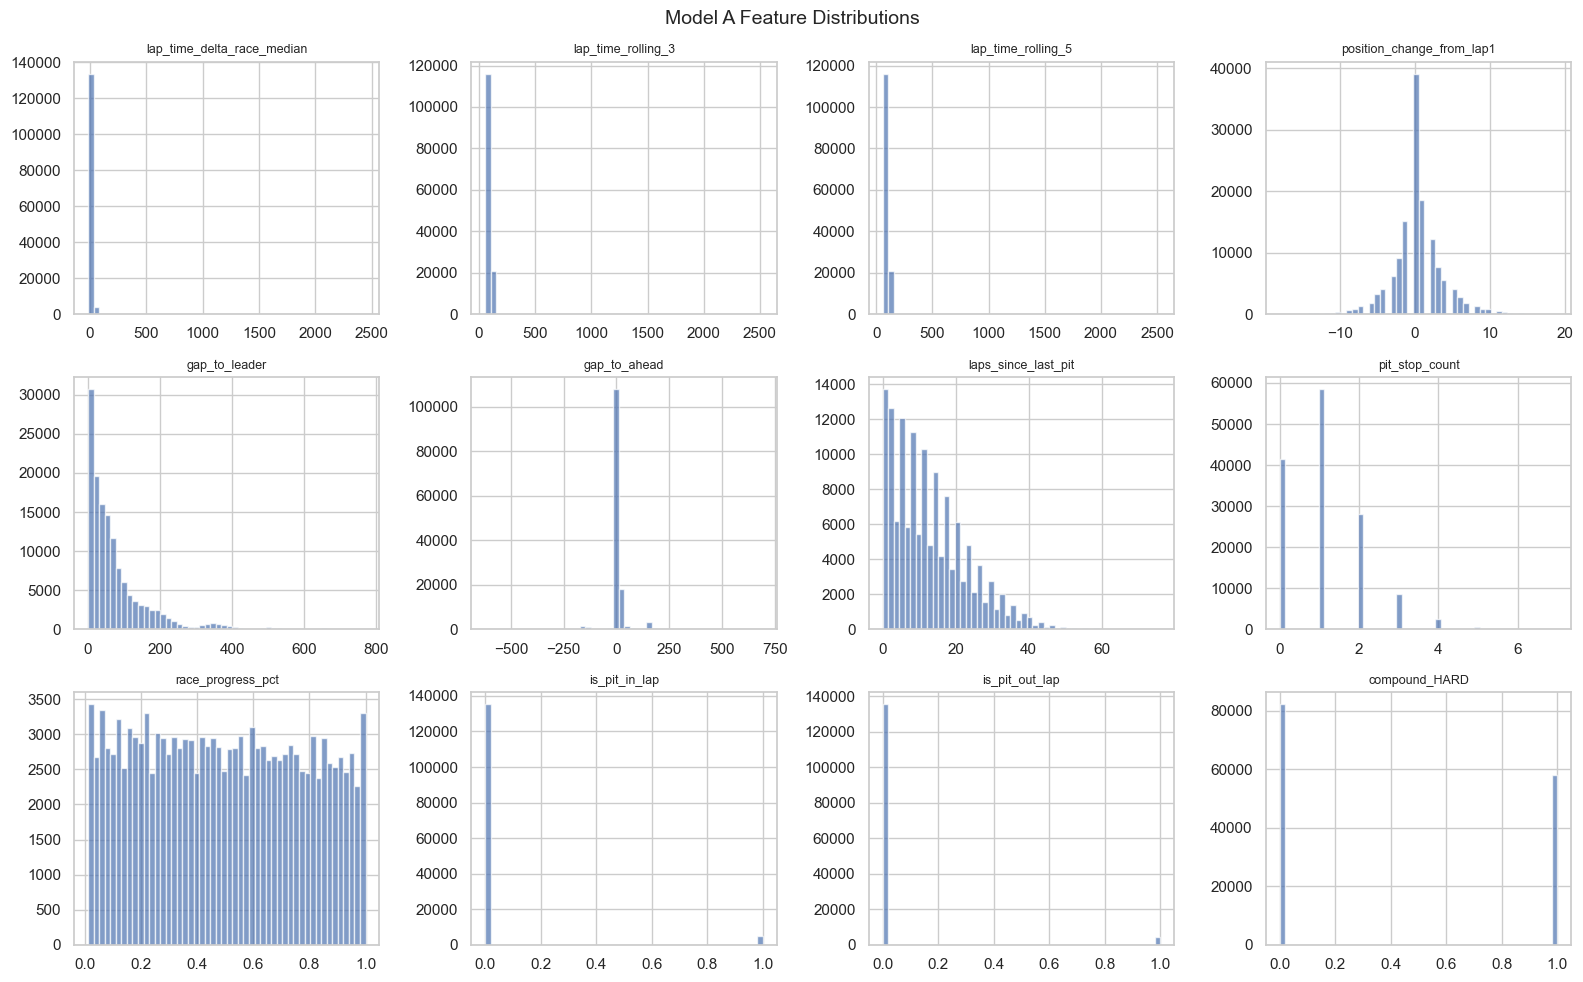

In [6]:
numeric_cols = features_a.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in numeric_cols if c not in ["season", "round", "lap_number", "position"]]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, feature_cols[:12]):
    features_a[col].dropna().hist(bins=50, ax=ax, alpha=0.7)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(feature_cols[:12]):]:
    ax.set_visible(False)
fig.suptitle("Model A Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

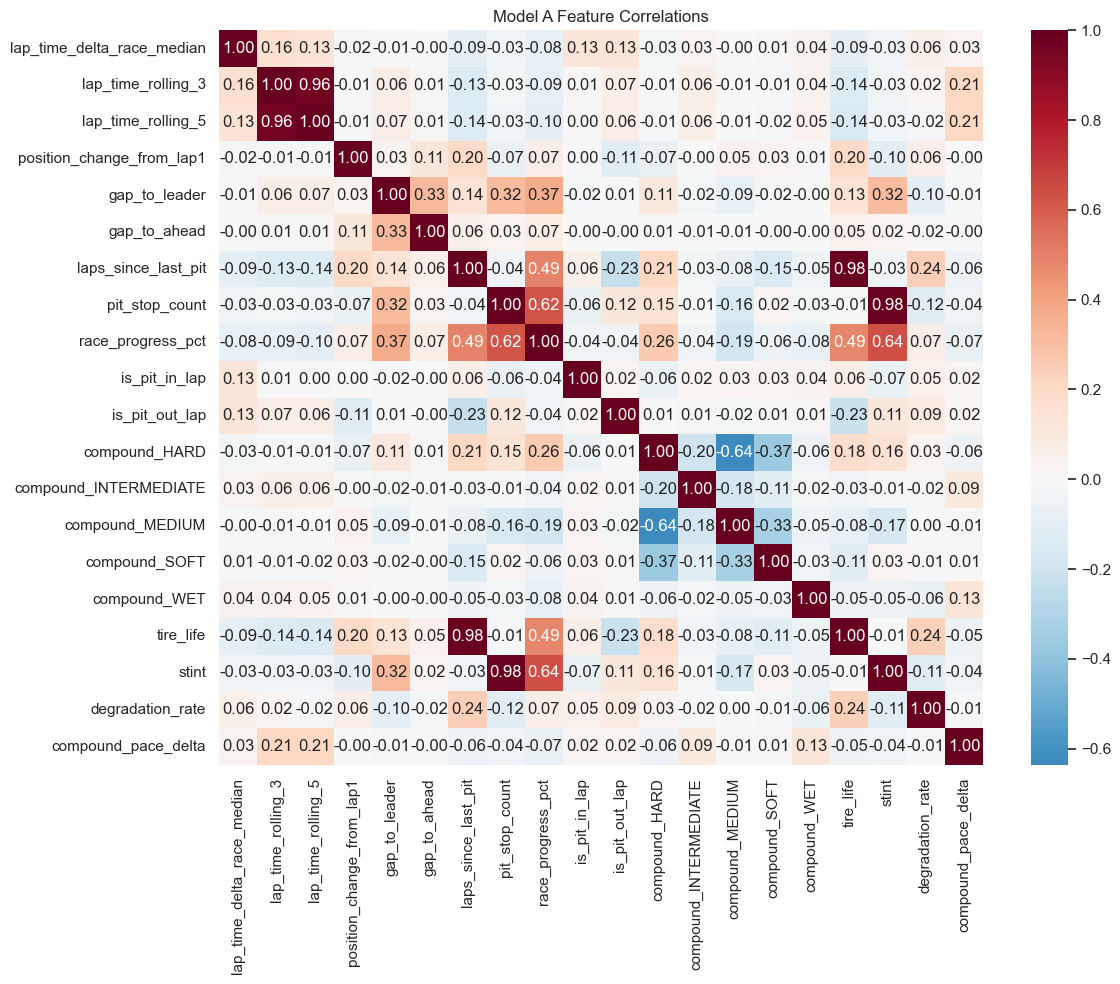

In [7]:
corr = features_a[feature_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title("Model A Feature Correlations")
plt.tight_layout()
plt.show()

In [8]:
splitter_a = LeaveOneSeasonOut()
groups_a = features_a["season"].values
print(f"Model A CV: {splitter_a.get_n_splits()} folds (LOSO)")
for i, (train_idx, val_idx) in enumerate(splitter_a.split(groups_a)):
    train_seasons = sorted(set(groups_a[train_idx]))
    val_seasons = sorted(set(groups_a[val_idx]))
    print(f"  Fold {i+1}: train={train_seasons} ({len(train_idx):,}), val={val_seasons} ({len(val_idx):,})")

train_idx, test_idx = splitter_a.get_test_split(groups_a)
print(f"  Test: seasons={sorted(set(groups_a[test_idx]))} ({len(test_idx):,})")

Model A CV: 5 folds (LOSO)
  Fold 1: train=[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] (89,680), val=[np.int64(2019)] (23,676)
  Fold 2: train=[np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)] (95,004), val=[np.int64(2020)] (18,352)
  Fold 3: train=[np.int64(2019), np.int64(2020), np.int64(2022), np.int64(2023)] (89,658), val=[np.int64(2021)] (23,698)
  Fold 4: train=[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2023)] (90,113), val=[np.int64(2022)] (23,243)
  Fold 5: train=[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)] (88,969), val=[np.int64(2023)] (24,387)
  Test: seasons=[np.int64(2024)] (26,606)


In [9]:
out_a = DATA_PROCESSED / "features_laps_tyre.parquet"
features_a.to_parquet(out_a, index=False)
print(f"Saved: {out_a} ({out_a.stat().st_size / 1024:.0f} KB)")

Saved: ..\data\processed\features_laps_tyre.parquet (5691 KB)


## 2. Model B — Lap Features WITHOUT Tyre (2018-2025)

In [10]:
features_b = build_lap_notyre_features(laps)
print(f"Model B features: {features_b.shape}")
print(f"Seasons: {sorted(features_b['season'].unique())}")
print(f"Columns: {list(features_b.columns)}")
features_b.head()

Model B features: (165128, 18)
Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Columns: ['season', 'round', 'event_name', 'driver_abbrev', 'team', 'lap_number', 'lap_time_delta_race_median', 'lap_time_rolling_3', 'lap_time_rolling_5', 'position_change_from_lap1', 'gap_to_leader', 'gap_to_ahead', 'laps_since_last_pit', 'pit_stop_count', 'race_progress_pct', 'is_pit_in_lap', 'is_pit_out_lap', 'position']


,season,round,event_name,driver_abbrev,team,lap_number,lap_time_delta_race_median,lap_time_rolling_3,lap_time_rolling_5,position_change_from_lap1,gap_to_leader,gap_to_ahead,laps_since_last_pit,pit_stop_count,race_progress_pct,is_pit_in_lap,is_pit_out_lap,position
0,2018,1,Australian Grand Prix,ALO,McLaren,1,11.584,NaN,NaN,0.0,7.295,0.963,0,0,0.017241,0,0,10.0
1,2018,1,Australian Grand Prix,ALO,McLaren,2,1.621,101.5280,101.5280,0.0,8.595,1.206,1,0,0.034483,0,0,10.0
2,2018,1,Australian Grand Prix,ALO,McLaren,3,1.360,96.5465,96.5465,0.0,10.090,1.243,2,0,0.051724,0,0,10.0
3,2018,1,Australian Grand Prix,ALO,McLaren,4,0.607,94.7990,94.7990,0.0,11.168,1.122,3,0,0.068966,0,0,10.0
4,2018,1,Australian Grand Prix,ALO,McLaren,5,1.966,91.1400,93.7370,0.0,13.917,1.198,4,0,0.086207,0,0,10.0


Missing values per column:
lap_time_delta_race_median    2814
lap_time_rolling_3            3950
lap_time_rolling_5            3490
position_change_from_lap1      261
gap_to_leader                 2814
gap_to_ahead                  2864
position                       261
dtype: int64


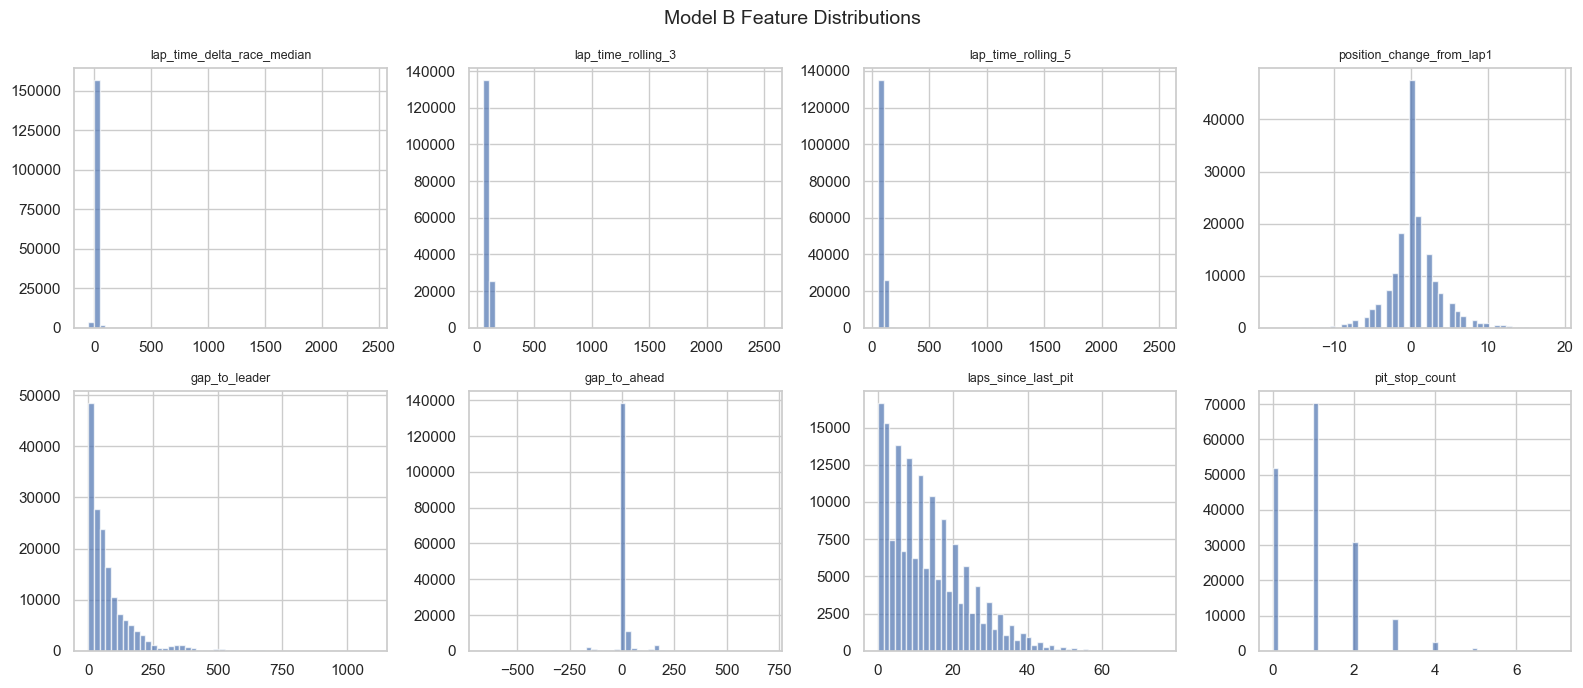

In [11]:
print("Missing values per column:")
missing_b = features_b.isnull().sum()
print(missing_b[missing_b > 0])

numeric_b = features_b.select_dtypes(include=[np.number]).columns
feature_cols_b = [c for c in numeric_b if c not in ["season", "round", "lap_number", "position"]]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, feature_cols_b[:8]):
    features_b[col].dropna().hist(bins=50, ax=ax, alpha=0.7)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(feature_cols_b[:8]):]:
    ax.set_visible(False)
fig.suptitle("Model B Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
splitter_b = ExpandingWindowSplit()
groups_b = features_b["season"].values
print(f"Model B CV: {splitter_b.get_n_splits()} folds (expanding window)")
for i, (train_idx, val_idx) in enumerate(splitter_b.split(groups_b)):
    train_seasons = sorted(set(groups_b[train_idx]))
    val_seasons = sorted(set(groups_b[val_idx]))
    print(f"  Fold {i+1}: train={train_seasons} ({len(train_idx):,}), val={val_seasons} ({len(val_idx):,})")

train_idx, test_idx = splitter_b.get_test_split(groups_b)
print(f"  Test: seasons={sorted(set(groups_b[test_idx]))} ({len(test_idx):,})")

Model B CV: 5 folds (expanding window)
  Fold 1: train=[np.int64(2018)] (22,337), val=[np.int64(2019)] (23,676)
  Fold 2: train=[np.int64(2018), np.int64(2019)] (46,013), val=[np.int64(2020)] (18,352)
  Fold 3: train=[np.int64(2018), np.int64(2019), np.int64(2020)] (64,365), val=[np.int64(2021)] (23,758)
  Fold 4: train=[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)] (88,123), val=[np.int64(2022)] (23,577)
  Fold 5: train=[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)] (111,700), val=[np.int64(2023)] (24,422)
  Test: seasons=[np.int64(2025)] (2,400)


In [13]:
out_b = DATA_PROCESSED / "features_laps_notyre.parquet"
features_b.to_parquet(out_b, index=False)
print(f"Saved: {out_b} ({out_b.stat().st_size / 1024:.0f} KB)")

Saved: ..\data\processed\features_laps_notyre.parquet (4722 KB)


## 3. Model C — Pre-Race Features (2018-2025)

In [14]:
features_c = build_race_features(races)
print(f"Model C features: {features_c.shape}")
print(f"Seasons: {sorted(features_c['season'].unique())}")
print(f"Columns: {list(features_c.columns)}")
features_c.head()

Model C features: (3458, 33)
Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Columns: ['season', 'round', 'event_name', 'driver_abbrev', 'team', 'best_quali_sec', 'quali_delta_to_pole', 'grid_position', 'quali_position_vs_teammate', 'avg_finish_last_3', 'avg_finish_last_5', 'points_last_3', 'points_cumulative_season', 'dnf_rate_season', 'position_trend', 'driver_circuit_avg_finish', 'driver_circuit_races', 'driver_circuit_podium_rate', 'driver_circuit_dnf_rate', 'team_avg_finish_last_3', 'team_points_cumulative_season', 'circuit_street', 'circuit_permanent', 'circuit_hybrid', 'circuit_avg_dnf_rate', 'weather_temp_max', 'weather_precip_mm', 'weather_wind_max_kph', 'is_wet_race', 'finish_position', 'is_podium', 'is_points_finish', 'is_dnf']


,season,round,event_name,driver_abbrev,team,best_quali_sec,quali_delta_to_pole,grid_position,quali_position_vs_teammate,avg_finish_last_3,...,circuit_hybrid,circuit_avg_dnf_rate,weather_temp_max,weather_precip_mm,weather_wind_max_kph,is_wet_race,finish_position,is_podium,is_points_finish,is_dnf
0,2018,1,Australian Grand Prix,ALO,McLaren,83.597,2.433,10.0,-1.0,NaN,...,1,NaN,23.4,5.2,39.8,1,5.0,False,True,False
1,2018,1,Australian Grand Prix,BOT,Mercedes,82.089,0.925,15.0,14.0,NaN,...,1,NaN,23.4,5.2,39.8,1,8.0,False,True,False
2,2018,1,Australian Grand Prix,ERI,Sauber,84.556,3.392,17.0,-1.0,NaN,...,1,NaN,23.4,5.2,39.8,1,19.0,False,False,True
3,2018,1,Australian Grand Prix,GAS,Toro Rosso,85.295,4.131,20.0,4.0,NaN,...,1,NaN,23.4,5.2,39.8,1,18.0,False,False,True
4,2018,1,Australian Grand Prix,GRO,Haas F1 Team,83.339,2.175,6.0,1.0,NaN,...,1,NaN,23.4,5.2,39.8,1,16.0,False,False,True


In [15]:
print("Missing values per column:")
missing_c = features_c.isnull().sum()
print(missing_c[missing_c > 0])

Missing values per column:
best_quali_sec                   1038
quali_delta_to_pole              1038
grid_position                       3
quali_position_vs_teammate          8
avg_finish_last_3                  43
avg_finish_last_5                  43
points_last_3                      43
points_cumulative_season          173
dnf_rate_season                   173
position_trend                    126
driver_circuit_avg_finish        1070
driver_circuit_races             1070
driver_circuit_podium_rate       1070
driver_circuit_dnf_rate          1070
team_avg_finish_last_3             42
team_points_cumulative_season     162
circuit_avg_dnf_rate              620
finish_position                     3
dtype: int64


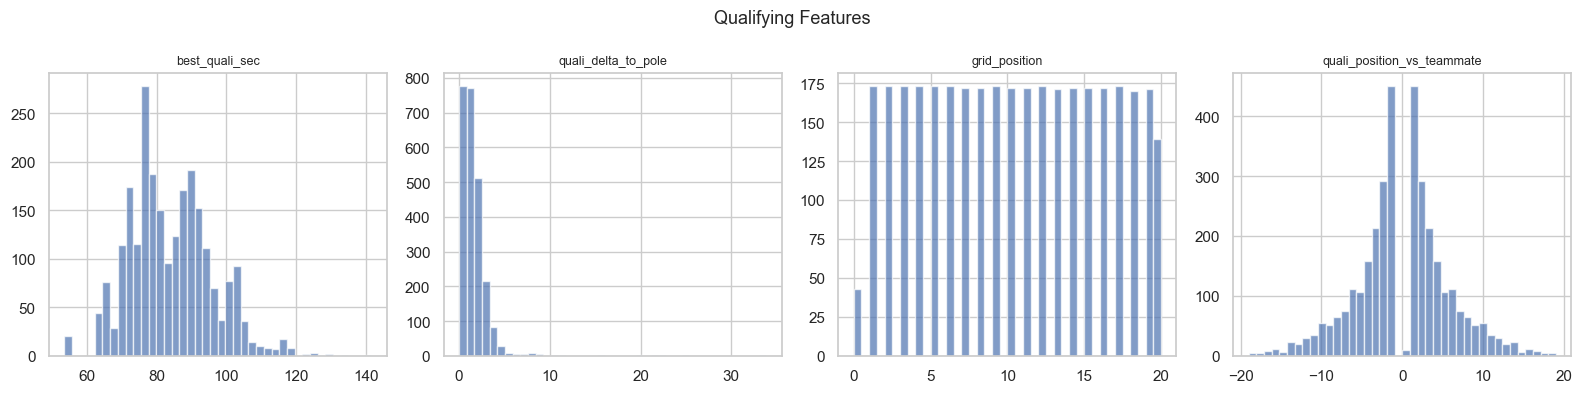

In [16]:
# Qualifying features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
quali_cols = ["best_quali_sec", "quali_delta_to_pole", "grid_position", "quali_position_vs_teammate"]
for ax, col in zip(axes, quali_cols):
    features_c[col].dropna().hist(bins=40, ax=ax, alpha=0.7)
    ax.set_title(col, fontsize=9)
fig.suptitle("Qualifying Features", fontsize=13)
plt.tight_layout()
plt.show()

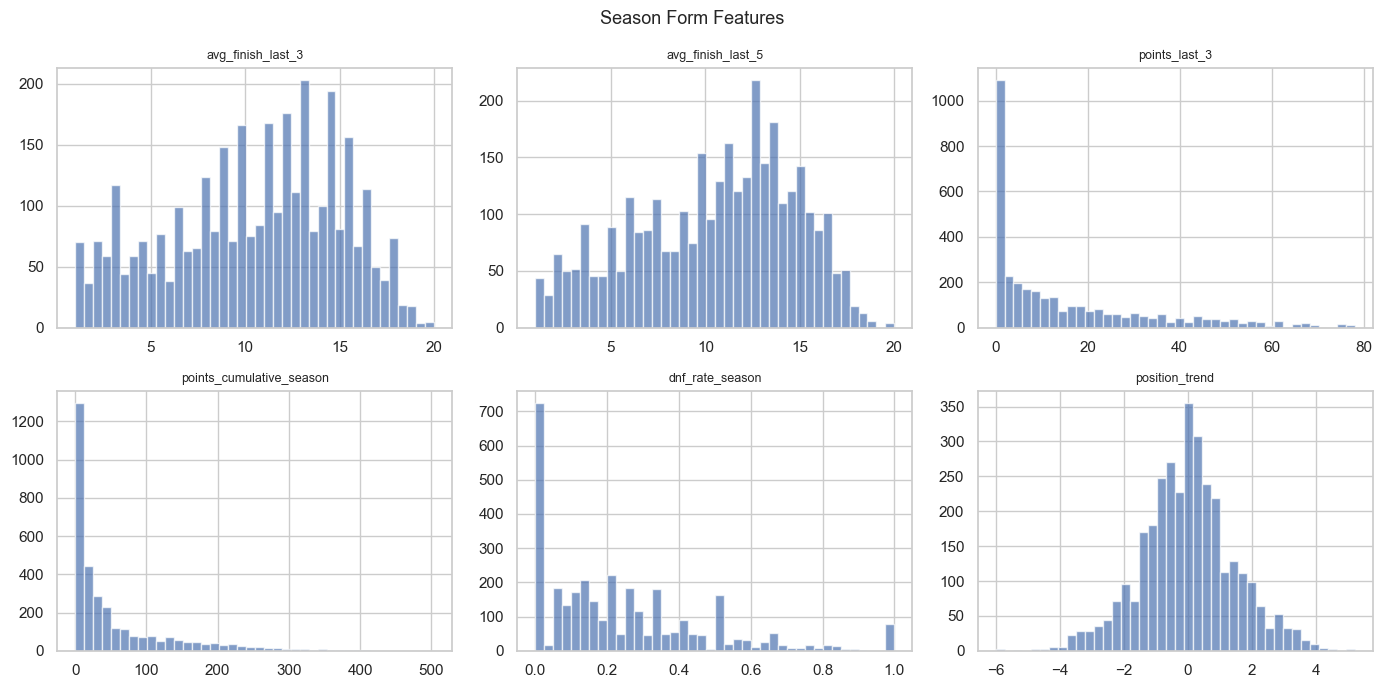

In [17]:
# Season form features
form_cols = ["avg_finish_last_3", "avg_finish_last_5", "points_last_3",
             "points_cumulative_season", "dnf_rate_season", "position_trend"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, form_cols):
    features_c[col].dropna().hist(bins=40, ax=ax, alpha=0.7)
    ax.set_title(col, fontsize=9)
fig.suptitle("Season Form Features", fontsize=13)
plt.tight_layout()
plt.show()

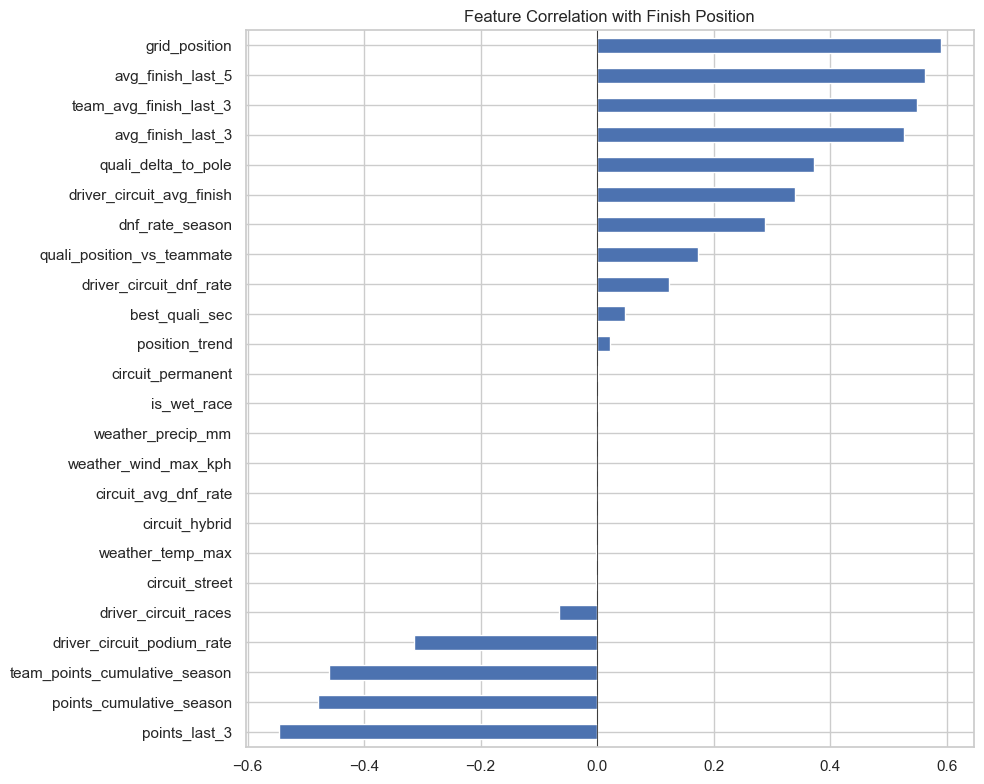

In [18]:
# Feature correlations with finish_position
numeric_c = features_c.select_dtypes(include=[np.number]).columns
feature_cols_c = [c for c in numeric_c
                  if c not in ["season", "round", "finish_position", "is_podium",
                               "is_points_finish", "is_dnf"]]
corr_with_target = features_c[feature_cols_c + ["finish_position"]].corr()["finish_position"].drop("finish_position")
corr_with_target = corr_with_target.dropna().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.plot.barh(ax=ax)
ax.set_title("Feature Correlation with Finish Position")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

In [19]:
# Leakage audit: removing round 5 should not change round 3 features
audit_races = races[races["season"] == 2022].copy()
audit_full = build_race_features(audit_races)
audit_truncated = build_race_features(audit_races[audit_races["round"] <= 4].copy())

r3_full = audit_full[audit_full["round"] == 3].sort_values("driver_abbrev").reset_index(drop=True)
r3_trunc = audit_truncated[audit_truncated["round"] == 3].sort_values("driver_abbrev").reset_index(drop=True)

check_cols = ["avg_finish_last_3", "points_last_3", "points_cumulative_season", "dnf_rate_season"]
for col in check_cols:
    pd.testing.assert_series_equal(
        r3_full[col], r3_trunc[col], check_names=False, obj=col
    )
print("Leakage audit PASSED: future data does not affect past features.")

Leakage audit PASSED: future data does not affect past features.


In [20]:
# CV split preview
splitter_c = ExpandingWindowSplit()
groups_c = features_c["season"].values
print(f"Model C CV: {splitter_c.get_n_splits()} folds (expanding window)")
for i, (train_idx, val_idx) in enumerate(splitter_c.split(groups_c)):
    train_seasons = sorted(set(groups_c[train_idx]))
    val_seasons = sorted(set(groups_c[val_idx]))
    print(f"  Fold {i+1}: train={train_seasons} ({len(train_idx):,}), val={val_seasons} ({len(val_idx):,})")

train_idx, test_idx = splitter_c.get_test_split(groups_c)
print(f"  Test: seasons={sorted(set(groups_c[test_idx]))} ({len(test_idx):,})")

Model C CV: 5 folds (expanding window)
  Fold 1: train=[np.int64(2018)] (420), val=[np.int64(2019)] (420)
  Fold 2: train=[np.int64(2018), np.int64(2019)] (840), val=[np.int64(2020)] (340)
  Fold 3: train=[np.int64(2018), np.int64(2019), np.int64(2020)] (1,180), val=[np.int64(2021)] (440)
  Fold 4: train=[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)] (1,620), val=[np.int64(2022)] (440)
  Fold 5: train=[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)] (2,060), val=[np.int64(2023)] (440)
  Test: seasons=[np.int64(2025)] (479)


In [21]:
out_c = DATA_PROCESSED / "features_race.parquet"
features_c.to_parquet(out_c, index=False)
print(f"Saved: {out_c} ({out_c.stat().st_size / 1024:.0f} KB)")

Saved: ..\data\processed\features_race.parquet (110 KB)


## 4. Summary

In [22]:
print("Feature Engineering Summary")
print("=" * 50)
for name, df, path in [
    ("Model A (lap+tyre)", features_a, out_a),
    ("Model B (lap, no tyre)", features_b, out_b),
    ("Model C (pre-race)", features_c, out_c),
]:
    size_kb = path.stat().st_size / 1024
    n_features = len([c for c in df.columns if c not in
                      ["season", "round", "event_name", "driver_abbrev", "team",
                       "lap_number", "position", "finish_position",
                       "is_podium", "is_points_finish", "is_dnf"]])
    print(f"\n{name}:")
    print(f"  Rows: {df.shape[0]:,}")
    print(f"  Features: {n_features}")
    print(f"  File: {path.name} ({size_kb:.0f} KB)")

print("\n" + "=" * 50)
print("Next steps: JOW-15 (Model Training)")

Feature Engineering Summary

Model A (lap+tyre):
  Rows: 139,962
  Features: 20
  File: features_laps_tyre.parquet (5691 KB)

Model B (lap, no tyre):
  Rows: 165,128
  Features: 11
  File: features_laps_notyre.parquet (4722 KB)

Model C (pre-race):
  Rows: 3,458
  Features: 24
  File: features_race.parquet (110 KB)

Next steps: JOW-15 (Model Training)
